# Tugas PCD: Pengukuran Kualitas Citra
**Dataset**: PH2 Dermoscopy Dataset (format `.bmp`)
**Metode**: Kompresi JPEG (Quality 10–50)
**Metrik**: PSNR, SSIM, VIF, LPIPS, FID

## 1. Instalasi Library

In [16]:
%pip install opencv-python scikit-image lpips sewar torch torchvision pandas matplotlib scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import Library

In [17]:
import os
import cv2
import glob
import torch
import lpips
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.linalg
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from sewar.full_ref import vifp

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


## 3. Load Dataset
Mengambil 25 citra `.bmp` dari folder `Dermoscopic_Image` (bukan mask).

Total citra BMP (Dermoscopic) ditemukan: 200
Jumlah sampel yang digunakan: 25


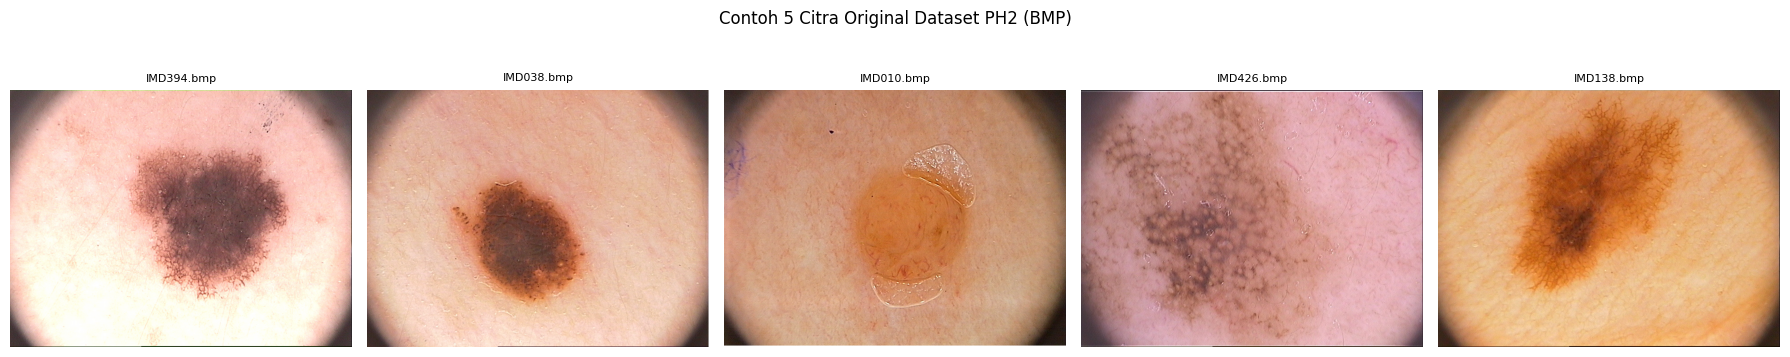

In [18]:
dataset_path = r"f:\UDINUS\SEMESTER 6\pcd\tugas_pengukuran_matrix\dataset\PH2Dataset\PH2 Dataset images"

# Cari semua file .bmp (bukan JPG sesuai ketentuan)
image_paths = glob.glob(os.path.join(dataset_path, "**", "*.bmp"), recursive=True)
# Filter: ambil hanya dari subfolder _Dermoscopic_Image (citra asli, bukan mask)
image_paths = [p for p in image_paths if "Dermoscopic_Image" in p]
print(f"Total citra BMP (Dermoscopic) ditemukan: {len(image_paths)}")

import random
random.seed(42)  # seed agar reproducible
sample_paths = random.sample(image_paths, 25)
print(f"Jumlah sampel yang digunakan: {len(sample_paths)}")

def load_images(paths):
    images = []
    names = []
    for p in paths:
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append(img)
        names.append(os.path.basename(p))
    return images, names

original_images, image_names = load_images(sample_paths)

# Tampilkan 5 contoh citra
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, ax in enumerate(axes):
    ax.imshow(original_images[i])
    ax.set_title(image_names[i], fontsize=8)
    ax.axis("off")
plt.suptitle("Contoh 5 Citra Original Dataset PH2 (BMP)", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Fungsi FID Manual
Implementasi FID menggunakan InceptionV3 dari `torchvision` langsung — **tanpa** dependensi `torch-fidelity`.

In [19]:
# ============================================================
# Fungsi Kalkulasi FID Manual (tanpa torch-fidelity)
# Menggunakan InceptionV3 dari torchvision sebagai feature extractor
# ============================================================

def get_inception_model():
    """Load InceptionV3 dan potong layer classifier untuk ekstraksi fitur."""
    model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
    # Hapus FC layer terakhir, gunakan average pool output (2048-dim)
    model.fc = nn.Identity()
    model.aux_logits = False
    model.eval()
    return model

def extract_features(images_np, model, device="cpu"):
    """Ekstrak fitur inception dari list numpy images (H, W, C, uint8)."""
    preprocess = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((299, 299)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    tensors = torch.stack([preprocess(img) for img in images_np]).to(device)
    with torch.no_grad():
        features = model(tensors)
    return features.cpu().numpy()

def calculate_fid(real_features, fake_features):
    """Hitung Frechet Inception Distance dari dua set fitur."""
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)
    
    # Hitung sqrt matrix covariance (Frechet distance)
    diff = mu1 - mu2
    covmean, _ = scipy.linalg.sqrtm(sigma1 @ sigma2, disp=False)
    
    # Tangani nilai imajiner kecil akibat numerical error
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return float(fid)

print("Fungsi FID manual siap digunakan.")

Fungsi FID manual siap digunakan.


## 5. Evaluasi Kompresi & Pengukuran Metrik
Melakukan kompresi JPEG dengan quality 10, 20, 30, 40, 50 lalu mengukur PSNR, SSIM, VIF, LPIPS, dan FID.

In [20]:
# ============================================================
# EVALUASI UTAMA: Kompresi + Pengukuran Metrik
# ============================================================

# Inisialisasi model
print("Memuat model LPIPS (VGG)...")
loss_fn_vgg = lpips.LPIPS(net="vgg")

print("Memuat model InceptionV3 untuk FID...")
inception_model = get_inception_model()

print("\nMulai evaluasi...\n")

# Preprocessing untuk LPIPS: tensor range [-1, 1]
def preprocess_lpips(img_np):
    t = transforms.ToTensor()(img_np)  # [0,1]
    t = t * 2 - 1                       # [-1,1]
    return t.unsqueeze(0)

quality_levels = [10, 20, 30, 40, 50]
results = []

# Ekstrak fitur original SEKALI SAJA (efisien)
print("Mengekstrak fitur InceptionV3 dari citra original...")
real_features = extract_features(original_images, inception_model)

for quality in quality_levels:
    print(f"\n--- Evaluasi Quality Level: {quality} ---")
    psnr_list, ssim_list, vif_list, lpips_list = [], [], [], []
    compressed_images = []

    for i, img in enumerate(original_images):
        # Kompresi JPEG in-memory (simulasi degradasi citra)
        encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
        _, encimg = cv2.imencode(".jpg", cv2.cvtColor(img, cv2.COLOR_RGB2BGR), encode_param)
        comp_img = cv2.imdecode(encimg, 1)
        comp_img = cv2.cvtColor(comp_img, cv2.COLOR_BGR2RGB)
        compressed_images.append(comp_img)

        # PSNR
        psnr_list.append(psnr(img, comp_img))

        # SSIM
        ssim_list.append(ssim(img, comp_img, channel_axis=2, data_range=255))

        # VIF
        vif_list.append(vifp(img, comp_img))

        # LPIPS
        with torch.no_grad():
            lpips_val = loss_fn_vgg(preprocess_lpips(img), preprocess_lpips(comp_img)).item()
        lpips_list.append(lpips_val)

    # FID (batch seluruh sampel)
    print(f"  Menghitung FID...")
    fake_features = extract_features(compressed_images, inception_model)
    fid_score = calculate_fid(real_features, fake_features)

    row = {
        "Quality": quality,
        "PSNR (dB)":   round(np.mean(psnr_list), 4),
        "SSIM":        round(np.mean(ssim_list), 4),
        "VIF":         round(np.mean(vif_list), 4),
        "LPIPS":       round(np.mean(lpips_list), 4),
        "FID":         round(fid_score, 4),
    }
    results.append(row)
    print(f"  PSNR={row['PSNR (dB)']:.2f} | SSIM={row['SSIM']:.4f} | "
          f"VIF={row['VIF']:.4f} | LPIPS={row['LPIPS']:.4f} | FID={row['FID']:.2f}")

df_results = pd.DataFrame(results)
print("\n=================== HASIL PENGUKURAN ===================")
display(df_results)

Memuat model LPIPS (VGG)...
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\lpips\weights\v0.1\vgg.pth
Memuat model InceptionV3 untuk FID...

Mulai evaluasi...

Mengekstrak fitur InceptionV3 dari citra original...

--- Evaluasi Quality Level: 10 ---
  Menghitung FID...


C:\Users\ACER\AppData\Local\Temp\ipykernel_20456\1322225564.py:36: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = scipy.linalg.sqrtm(sigma1 @ sigma2, disp=False)


  PSNR=29.45 | SSIM=0.6964 | VIF=0.1458 | LPIPS=0.5991 | FID=141.94

--- Evaluasi Quality Level: 20 ---
  Menghitung FID...
  PSNR=32.04 | SSIM=0.7745 | VIF=0.2325 | LPIPS=0.4569 | FID=57.03

--- Evaluasi Quality Level: 30 ---
  Menghitung FID...
  PSNR=33.21 | SSIM=0.8108 | VIF=0.2837 | LPIPS=0.3628 | FID=31.03

--- Evaluasi Quality Level: 40 ---
  Menghitung FID...
  PSNR=33.90 | SSIM=0.8313 | VIF=0.3168 | LPIPS=0.3121 | FID=21.86

--- Evaluasi Quality Level: 50 ---
  Menghitung FID...
  PSNR=34.44 | SSIM=0.8464 | VIF=0.3437 | LPIPS=0.2794 | FID=16.35

=================== HASIL PENGUKURAN ===================


,Quality,PSNR (dB),SSIM,VIF,LPIPS,FID
0,10,29.4456,0.6964,0.1458,0.5991,141.9402
1,20,32.0418,0.7745,0.2325,0.4569,57.0262
2,30,33.2132,0.8108,0.2837,0.3628,31.0331
3,40,33.8992,0.8313,0.3168,0.3121,21.8642
4,50,34.4368,0.8464,0.3437,0.2794,16.3538


## 6. Visualisasi Grafik Metrik

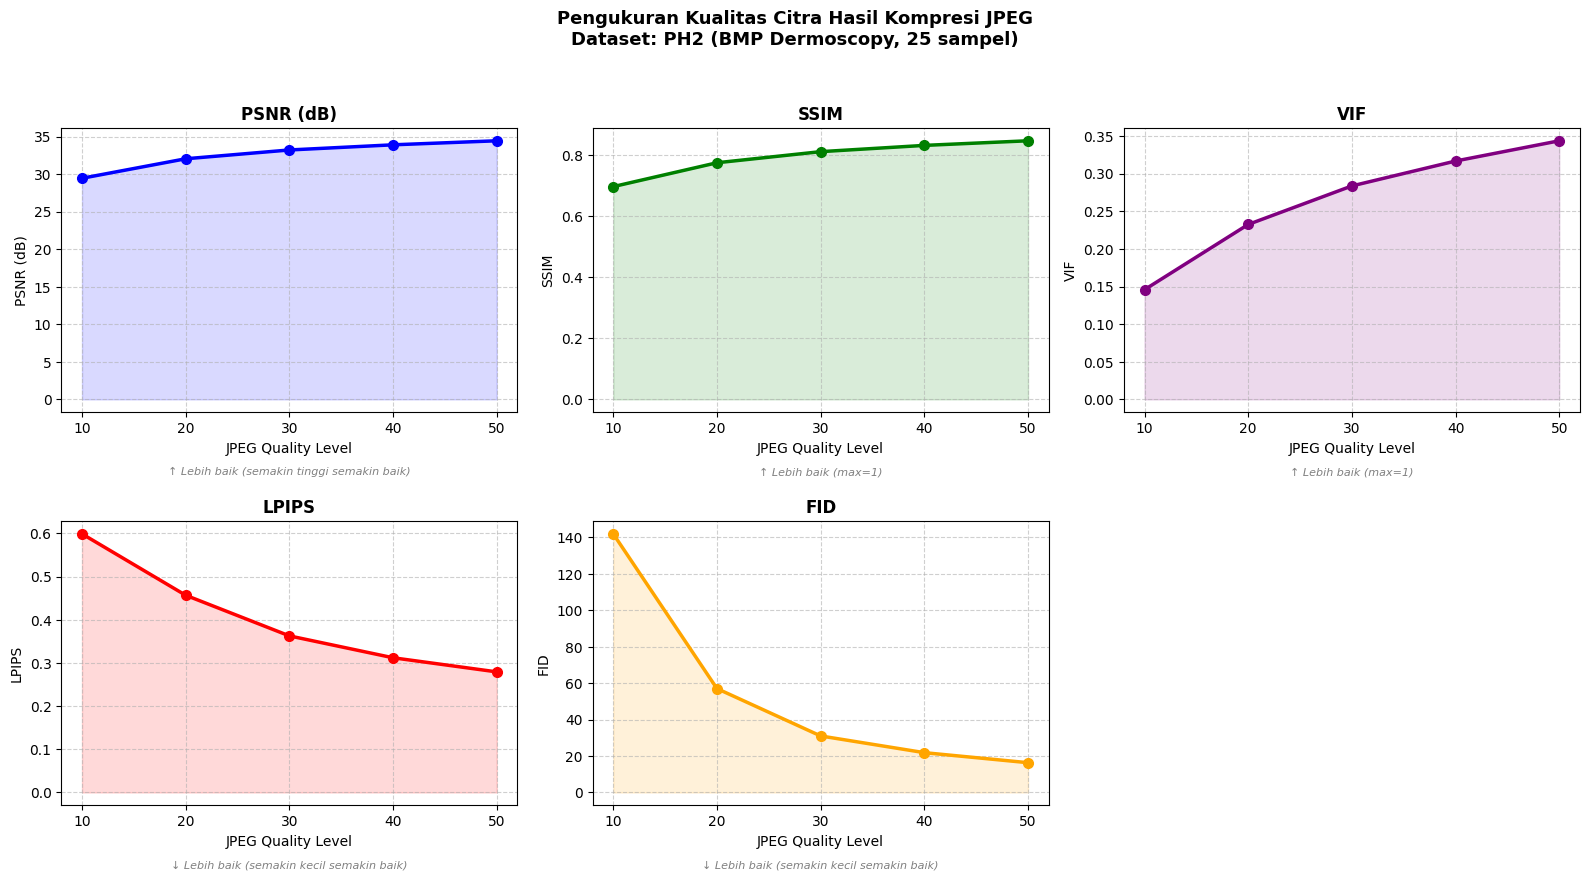

Grafik tersimpan sebagai 'hasil_pengukuran.png'


In [21]:
# ============================================================
# VISUALISASI HASIL PENGUKURAN
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Pengukuran Kualitas Citra Hasil Kompresi JPEG\nDataset: PH2 (BMP Dermoscopy, 25 sampel)",
             fontsize=13, fontweight="bold")

metrics_info = [
    ("PSNR (dB)",  "blue",   "↑ Lebih baik (semakin tinggi semakin baik)"),
    ("SSIM",       "green",  "↑ Lebih baik (max=1)"),
    ("VIF",        "purple", "↑ Lebih baik (max=1)"),
    ("LPIPS",      "red",    "↓ Lebih baik (semakin kecil semakin baik)"),
    ("FID",        "orange", "↓ Lebih baik (semakin kecil semakin baik)"),
]

for ax, (metric, color, note) in zip(axes.flat, metrics_info):
    ax.plot(df_results["Quality"], df_results[metric],
            marker="o", color=color, linewidth=2.5, markersize=7)
    ax.fill_between(df_results["Quality"], df_results[metric],
                    alpha=0.15, color=color)
    ax.set_title(f"{metric}", fontsize=12, fontweight="bold")
    ax.set_xlabel("JPEG Quality Level", fontsize=10)
    ax.set_ylabel(metric, fontsize=10)
    ax.text(0.5, -0.22, note, transform=ax.transAxes, fontsize=8,
            ha="center", color="gray", style="italic")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_xticks([10, 20, 30, 40, 50])

# Sembunyikan subplot terakhir yang kosong
axes.flat[-1].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("hasil_pengukuran.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik tersimpan sebagai 'hasil_pengukuran.png'")

## 7. Perbandingan Visual Citra Original vs Compressed

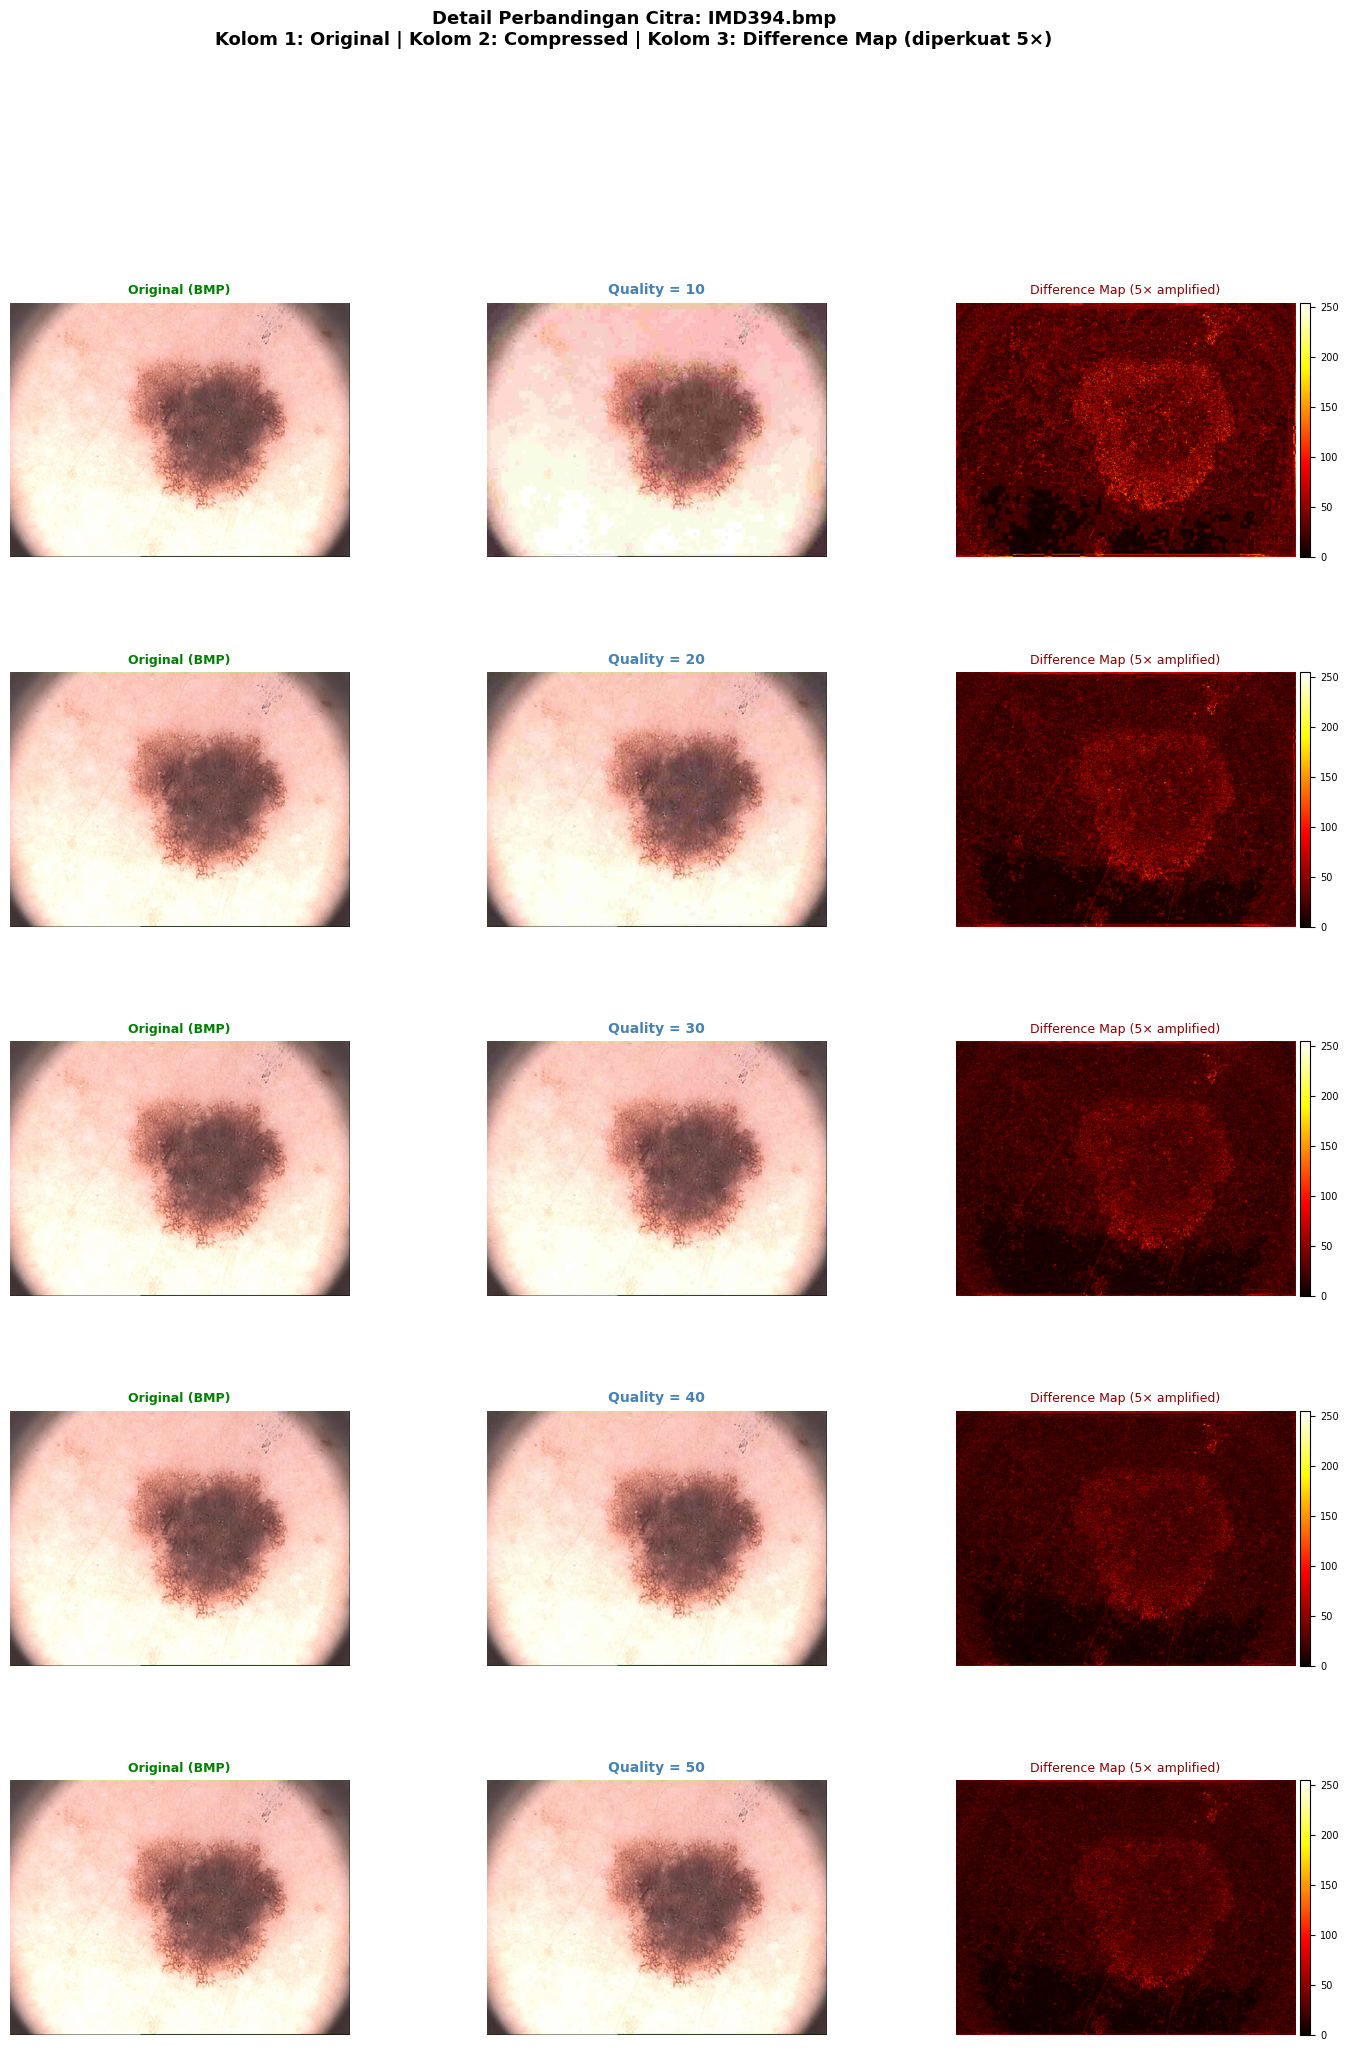

Gambar detail perbandingan tersimpan sebagai 'detail_perbandingan.png'


In [22]:
# ============================================================
# VISUALISASI DETAIL PERBANDINGAN: Original vs Compressed vs Difference Map
# Setiap quality level ditampilkan dalam 1 baris:
#   [Original] | [Compressed] | [Difference Map (diperkuat)]
# ============================================================

import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

sample_img  = original_images[0]
sample_name = image_names[0]
qualities   = [10, 20, 30, 40, 50]

# Precompute semua hasil kompresi + metrik
compressed_list, metrics_list = [], []
for q in qualities:
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), q]
    _, encimg = cv2.imencode(".jpg", cv2.cvtColor(sample_img, cv2.COLOR_RGB2BGR), encode_param)
    comp = cv2.imdecode(encimg, 1)
    comp = cv2.cvtColor(comp, cv2.COLOR_BGR2RGB)
    compressed_list.append(comp)

    p  = psnr(sample_img, comp)
    s  = ssim(sample_img, comp, channel_axis=2, data_range=255)
    v  = vifp(sample_img, comp)
    with torch.no_grad():
        lp = loss_fn_vgg(
            (transforms.ToTensor()(sample_img) * 2 - 1).unsqueeze(0),
            (transforms.ToTensor()(comp)       * 2 - 1).unsqueeze(0)
        ).item()
    metrics_list.append({"q": q, "psnr": p, "ssim": s, "vif": v, "lpips": lp})

# ---- Layout: 5 baris (satu per quality) x 3 kolom ----
n_rows = len(qualities)
fig = plt.figure(figsize=(18, 4.5 * n_rows))
fig.suptitle(
    f"Detail Perbandingan Citra: {sample_name}\n"
    "Kolom 1: Original | Kolom 2: Compressed | Kolom 3: Difference Map (diperkuat 5×)",
    fontsize=13, fontweight="bold", y=1.01
)

gs = gridspec.GridSpec(n_rows, 3, figure=fig, hspace=0.45, wspace=0.08)

for row_idx, (comp, m) in enumerate(zip(compressed_list, metrics_list)):
    q = m["q"]

    # --- Hitung difference map ---
    diff = np.abs(sample_img.astype(np.int16) - comp.astype(np.int16)).astype(np.uint8)
    diff_amplified = np.clip(diff * 5, 0, 255).astype(np.uint8)   # perkuat 5x agar terlihat
    diff_gray = cv2.cvtColor(diff_amplified, cv2.COLOR_RGB2GRAY)   # grayscale untuk heatmap
    max_diff  = diff.max()
    mean_diff = diff.mean()

    # --- (1) Original ---
    ax1 = fig.add_subplot(gs[row_idx, 0])
    ax1.imshow(sample_img)
    ax1.set_title("Original (BMP)", fontsize=9, color="green", fontweight="bold")
    ax1.axis("off")
    if row_idx == 0:
        ax1.set_xlabel("↑ Referensi", fontsize=8, color="gray")

    # --- (2) Compressed ---
    ax2 = fig.add_subplot(gs[row_idx, 1])
    ax2.imshow(comp)
    ax2.set_title(
        f"Quality = {q}",
        fontsize=10, fontweight="bold", color="steelblue"
    )
    ax2.set_xlabel(
        f"PSNR: {m['psnr']:.2f} dB  |  SSIM: {m['ssim']:.4f}\n"
        f"VIF:  {m['vif']:.4f}  |  LPIPS: {m['lpips']:.4f}",
        fontsize=8.5, labelpad=6
    )
    ax2.axis("off")

    # --- (3) Difference Map (heatmap) ---
    ax3 = fig.add_subplot(gs[row_idx, 2])
    im = ax3.imshow(diff_gray, cmap="hot", vmin=0, vmax=255)
    ax3.set_title("Difference Map (5× amplified)", fontsize=9, color="darkred")
    ax3.set_xlabel(
        f"Max diff: {max_diff} px  |  Mean diff: {mean_diff:.2f} px",
        fontsize=8.5, labelpad=6
    )
    ax3.axis("off")

    # Colorbar kecil di samping heatmap
    divider = make_axes_locatable(ax3)
    cax = divider.append_axes("right", size="3%", pad=0.05)
    plt.colorbar(im, cax=cax)
    cax.tick_params(labelsize=7)

plt.savefig("detail_perbandingan.png", dpi=130, bbox_inches="tight")
plt.show()
print("Gambar detail perbandingan tersimpan sebagai 'detail_perbandingan.png'")